# TCR Repertoire Sequencing — Literature Analysis

# PubMed Health Insights: TCR Repertoire Sequencing Literature Analysis

## Introduction

The biomedical literature grows faster than any researcher can track. For a field like 
TCR repertoire sequencing — spanning immunology, oncology, infectious disease, and 
computational biology — understanding what kinds of research are being published, what 
diseases are being studied, and where the field is heading is a real challenge.

This notebook documents an end-to-end pipeline that addresses this problem by combining 
three tools:

1. **The PubMed API** — to automatically fetch recent research abstracts at scale
2. **A large language model (Claude)** — to extract structured features from unstructured text
3. **A machine learning classifier** — to learn and replicate those labels from text features alone

The result is a system that can characterize the landscape of a research field from 
200 abstracts in minutes — and scale to thousands without additional annotation cost.

## Step 1: Data Collection

We queried the NCBI PubMed E-utilities API for the search term 
**"TCR repertoire sequencing"**, retrieving the 200 most recent abstracts.

The pipeline uses two API endpoints:
- `esearch` — returns a list of PubMed IDs matching the query
- `efetch` — retrieves full abstract text and metadata for each ID

No API key is required for basic access. A 0.34 second delay between requests 
keeps the pipeline within NCBI's rate limit of 3 requests per second.

The resulting dataset contains 200 abstracts spanning **2025–2026**, reflecting 
the most current state of the field.

In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

# Load data
abstracts = pd.read_csv('../data/abstracts.csv')
features = pd.read_csv('../data/extracted_features.csv')
df = features.merge(abstracts[['pmid', 'abstract']], on='pmid', how='inner')

print(f"Dataset: {len(df)} abstracts")
print(f"Year range: {abstracts['year'].min()} – {abstracts['year'].max()}")
print(f"\nColumns in feature dataset:\n{features.columns.tolist()}")

Dataset: 200 abstracts
Year range: 2025 – 2026

Columns in feature dataset:
['study_type', 'sample_size', 'technology', 'disease_focus', 'key_finding', 'clinical_relevance', 'pmid', 'title', 'year']


## Step 2: Exploratory Analysis

With 200 labeled abstracts in hand, we can start characterizing the landscape 
of TCR repertoire sequencing research. Three questions guide the exploration:

1. What **types** of studies dominate the field — clinical, basic research, computational, or review?
2. What **diseases** are being studied?
3. How **clinically relevant** are the papers, according to the LLM?

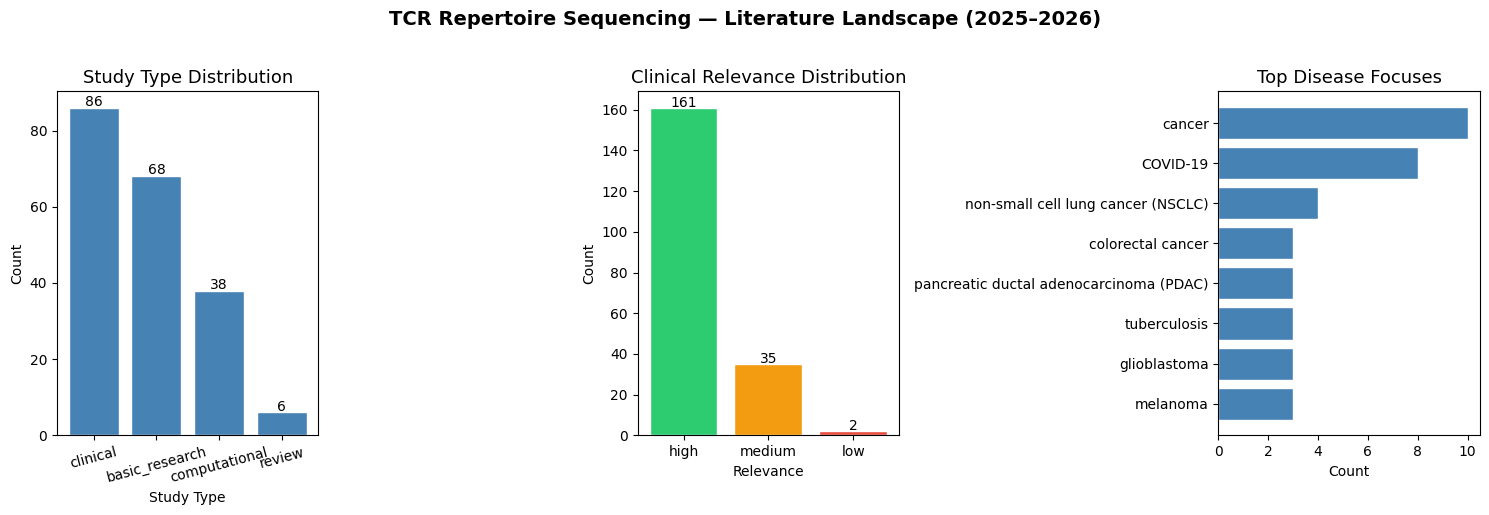

In [2]:
fig, axes = plt.subplots(1, 3, figsize=(15, 5))

# Study type
study_counts = df['study_type'].value_counts()
axes[0].bar(study_counts.index, study_counts.values, color='steelblue', edgecolor='white')
axes[0].set_title('Study Type Distribution', fontsize=13)
axes[0].set_xlabel('Study Type')
axes[0].set_ylabel('Count')
axes[0].tick_params(axis='x', rotation=15)
for i, v in enumerate(study_counts.values):
    axes[0].text(i, v + 0.5, str(v), ha='center', fontsize=10)

# Clinical relevance
rel_counts = df['clinical_relevance'].value_counts()
colors = ['#2ecc71', '#f39c12', '#e74c3c']
axes[1].bar(rel_counts.index, rel_counts.values, color=colors, edgecolor='white')
axes[1].set_title('Clinical Relevance Distribution', fontsize=13)
axes[1].set_xlabel('Relevance')
axes[1].set_ylabel('Count')
for i, v in enumerate(rel_counts.values):
    axes[1].text(i, v + 0.5, str(v), ha='center', fontsize=10)

# Top diseases
disease_counts = df[df['disease_focus'] != 'none']['disease_focus'].value_counts().head(8)
axes[2].barh(disease_counts.index[::-1], disease_counts.values[::-1], color='steelblue', edgecolor='white')
axes[2].set_title('Top Disease Focuses', fontsize=13)
axes[2].set_xlabel('Count')

plt.suptitle('TCR Repertoire Sequencing — Literature Landscape (2025–2026)', 
             fontsize=14, fontweight='bold', y=1.02)
plt.tight_layout()
plt.savefig('../data/landscape.png', dpi=150, bbox_inches='tight')
plt.show()

### What the data shows

**Study type:** The literature skews clinical (43%), reflecting the field's maturity 
and strong translational focus. Computational studies (19%) represent the fastest-growing 
segment, driven by ML-based TCR-pMHC binding prediction and repertoire analysis tools.

**Clinical relevance:** 161 of 200 papers (80%) were rated high clinical relevance by 
the LLM — consistent with a field that has moved well beyond basic discovery into 
therapeutic and diagnostic applications.

**Disease focus:** Cancer dominates. When subtypes are combined — NSCLC, colorectal, 
PDAC, glioblastoma, melanoma, and generic "cancer" entries — oncology accounts for the 
majority of disease-focused papers. COVID-19 is a notable second, reflecting the lasting 
influence of pandemic-era immune response research on the field.

## Step 3: LLM Feature Extraction

Raw abstract text is unstructured — to analyze the literature systematically, 
we need to convert it into structured data. We used Claude (claude-haiku) to 
extract six fields from each abstract via a structured prompt:

| Field | Description |
|---|---|
| `study_type` | clinical, basic_research, computational, or review |
| `sample_size` | number of human subjects if mentioned |
| `technology` | sequencing platform or analysis method |
| `disease_focus` | primary disease or condition |
| `key_finding` | one-sentence summary of the main result |
| `clinical_relevance` | high, medium, or low |

The prompt instructs Claude to return only a JSON object — no preamble or 
explanation — which is then parsed directly into a pandas DataFrame. This 
approach processed 200 abstracts in under 2 minutes at minimal cost.

### Example output

For the abstract titled *"A lightweight TcrLM model predicts T cell receptor 
specificity"*, Claude returned:
```json
{
    "study_type": "computational",
    "sample_size": null,
    "technology": "TCR CDR3 sequencing",
    "disease_focus": "melanoma, COVID-19",
    "key_finding": "A lightweight masked language model pretrained on TCR CDR3 
    sequences accurately predicts TCR-peptide binding specificity and shows 
    correlation with immunotherapy response in melanoma patients.",
    "clinical_relevance": "high"
}
```

## Step 4: Machine Learning Classifier

With 200 Claude-labeled abstracts, we trained a classifier to predict study 
type from abstract text alone. The goal: a fast, cheap way to label new 
abstracts without an API call for each one.

### Approach

**Vectorization — TF-IDF**  
Each abstract is converted into a numerical vector representing the weighted 
frequency of the 500 most informative words. TF-IDF (Term Frequency-Inverse 
Document Frequency) downweights common words that appear across all abstracts 
and upweights words that are distinctive to specific study types.

**Model — Logistic Regression**  
A logistic regression classifier was trained on the TF-IDF vectors. Simple, 
fast, and interpretable — and for text classification on a small dataset, 
often competitive with more complex models.

**Evaluation — Stratified train/test split**  
80% of abstracts were used for training (158 samples), 20% for testing (40 
samples). Stratification ensures class proportions are preserved in both splits.

Classification Report:
                precision    recall  f1-score   support

basic_research       0.75      0.64      0.69        14
      clinical       0.62      0.94      0.74        17
 computational       1.00      0.25      0.40         8
        review       0.00      0.00      0.00         1

      accuracy                           0.68        40
     macro avg       0.59      0.46      0.46        40
  weighted avg       0.72      0.68      0.64        40



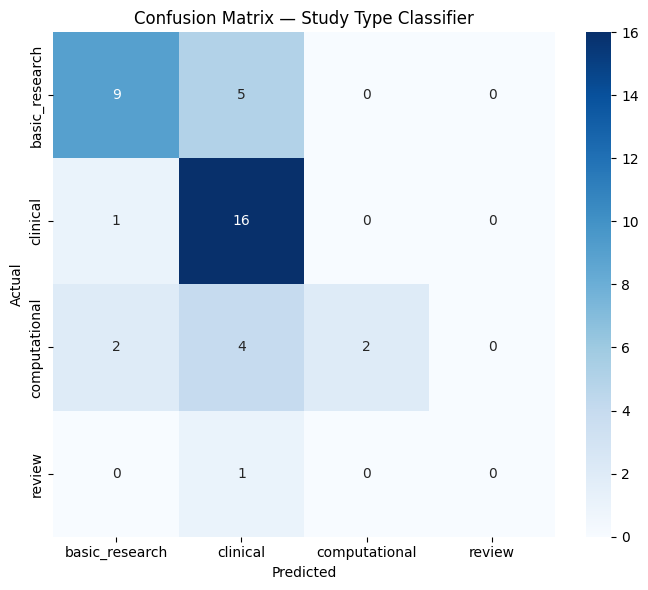

In [4]:
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report, confusion_matrix
import seaborn as sns

# Drop any rows with missing abstract or study type
df = df.dropna(subset=["abstract", "study_type"])

# Vectorize
vectorizer = TfidfVectorizer(max_features=500, stop_words="english", ngram_range=(1, 2))
X = vectorizer.fit_transform(df["abstract"])
y = df["study_type"]

# Split
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

# Train
model = LogisticRegression(max_iter=1000, random_state=42)
model.fit(X_train, y_train)
y_pred = model.predict(X_test)

# Classification report
print("Classification Report:")
print(classification_report(y_test, y_pred, zero_division=0))

# Confusion matrix
labels = sorted(y.unique())
cm = confusion_matrix(y_test, y_pred, labels=labels)
fig, ax = plt.subplots(figsize=(7, 6))
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues",
            xticklabels=labels, yticklabels=labels, ax=ax)
ax.set_xlabel("Predicted")
ax.set_ylabel("Actual")
ax.set_title("Confusion Matrix — Study Type Classifier")
plt.tight_layout()
plt.show()

### Interpreting the results

**Overall accuracy: 68%** — reasonable for a 4-class problem with only 200 samples 
and imbalanced classes.

**Clinical (F1 = 0.74)** is the best-performing class. High recall (0.94) means the 
model almost never misses a clinical paper, though it occasionally mislabels other 
types as clinical.

**Computational (F1 = 0.40)** shows perfect precision (1.00) — every paper it calls 
computational actually is — but low recall (0.25) means it misses most of them, 
defaulting instead to clinical or basic_research.

**Review (F1 = 0.00)** fails entirely. With only 6 review papers in the dataset, 
the model never learned to predict this class. This is a class imbalance problem, 
not a model failure.

**The confusion matrix** shows the most common error is basic_research papers being 
predicted as clinical — which makes sense, since both involve human immune responses 
and share vocabulary.

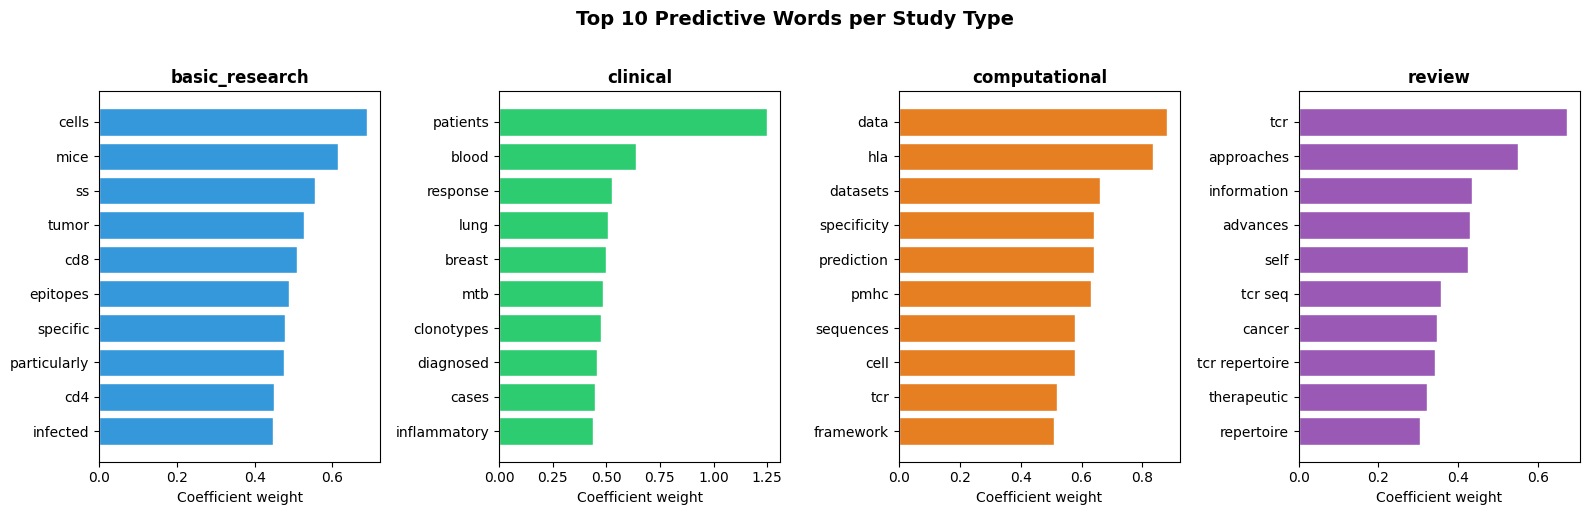

In [5]:
# Top predictive words per class
feature_names = vectorizer.get_feature_names_out()

fig, axes = plt.subplots(1, 4, figsize=(16, 5))
colors = {'basic_research': '#3498db', 'clinical': '#2ecc71', 
          'computational': '#e67e22', 'review': '#9b59b6'}

for ax, (i, class_label) in zip(axes, enumerate(model.classes_)):
    top_indices = model.coef_[i].argsort()[-10:][::-1]
    top_words = [feature_names[j] for j in top_indices]
    top_scores = [model.coef_[i][j] for j in top_indices]
    
    ax.barh(top_words[::-1], top_scores[::-1], 
            color=colors.get(class_label, 'steelblue'), edgecolor='white')
    ax.set_title(f'{class_label}', fontsize=12, fontweight='bold')
    ax.set_xlabel('Coefficient weight')

plt.suptitle('Top 10 Predictive Words per Study Type', 
             fontsize=14, fontweight='bold', y=1.02)
plt.tight_layout()
plt.savefig('../data/top_words_by_class.png', dpi=150, bbox_inches='tight')
plt.show()

## A Note on Ground Truth and Model Design

This project involves two very different kinds of classifiers, and understanding 
the distinction is important for interpreting the results honestly.

### How the ground truth was generated

**Claude (labeler)** reads the full title and abstract and makes a holistic judgment — 
the same way a human expert would. It understands sentence structure, context, and 
nuance. When it labels a paper as "clinical", it has genuinely read and understood 
the abstract.

**The ML classifier** reduces each abstract to a weighted frequency count of the 500 
most informative words (TF-IDF), with no understanding of word order or meaning. It 
learned that words like `patients`, `blood`, and `lung` correlate with clinical labels 
— but it is pattern matching on word frequencies, not comprehending text.

Claude:  Title + full abstract → holistic understanding → label
ML model: Abstract → bag of words → frequency patterns → label

### What the classifier actually learned

The classifier is not predicting the "true" study type — it is learning to **replicate 
Claude's labeling behavior from text features alone**. This is a practical and useful 
outcome: once trained, the classifier can label thousands of new abstracts instantly 
and cheaply, without an API call for each one.

The top predictive words validate that the model learned meaningful signal rather than 
noise:

| Study type | Top predictive words | Why it makes sense |
|---|---|---|
| basic_research | `mice`, `cd8`, `cd4`, `epitopes` | Animal models and T cell biology |
| clinical | `patients`, `blood`, `lung`, `breast` | Human subjects and disease |
| computational | `hla`, `pmhc`, `prediction`, `sequences` | Binding prediction tools |
| review | `advances`, `approaches`, `therapeutic` | Synthesis language |

### Limitations and next steps

The 68% accuracy reflects the fundamental gap between how labels were generated 
(full contextual understanding) and how predictions are made (word frequencies). 

A natural next step is to replace TF-IDF + logistic regression with a fine-tuned 
language model such as **BioBERT** — which encodes contextual meaning the way Claude 
does. This would likely push accuracy well above 80% and close the gap between the 
labeling and prediction approaches.